In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install pandas numpy matplotlib scikit-learn seaborn

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
data = pd.read_csv(r'insclass_train.csv')
data.head(6)

,variable_1,variable_2,variable_3,variable_4,variable_5,variable_6,variable_7,variable_8,variable_9,variable_10,...,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,target
0,w200,0,0,14,q2,98.0,NaN,0.0,NaN,0,...,C,j2,h45,0,0.0,0,1,19.323463,t1,0
1,w160,0,0,7,q11,106.0,NaN,0.0,NaN,0,...,C,j33,h234,0,1.0,0,1,41.177900,t1,0
2,w200,0,0,4,q3,123.0,NaN,0.0,NaN,0,...,B,j12,h28,0,0.0,0,1,3.614395,t1,0
3,w200,0,0,9,q3,102.0,NaN,0.0,NaN,0,...,C,j12,h64,0,1.0,0,0,49.041674,t1,0
4,w200,0,0,18,q20,117.0,NaN,0.0,NaN,0,...,C,j111,h991,0,1.0,0,0,17.909612,t1,0
5,w160,0,0,27,q0,70.0,NaN,0.0,NaN,0,...,C,j11,h504,0,0.0,0,1,19.323463,t1,0


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 151406 entries, 0 to 151405
Data columns (total 29 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   variable_1   151406 non-null  str    
 1   variable_2   151406 non-null  int64  
 2   variable_3   151406 non-null  int64  
 3   variable_4   151406 non-null  int64  
 4   variable_5   151406 non-null  str    
 5   variable_6   151295 non-null  float64
 6   variable_7   55767 non-null   float64
 7   variable_8   121507 non-null  float64
 8   variable_9   16970 non-null   float64
 9   variable_10  151406 non-null  int64  
 10  variable_11  151406 non-null  int64  
 11  variable_12  149878 non-null  float64
 12  variable_13  149749 non-null  float64
 13  variable_14  148479 non-null  float64
 14  variable_15  13 non-null      float64
 15  variable_16  151394 non-null  float64
 16  variable_17  151394 non-null  float64
 17  variable_18  151394 non-null  float64
 18  variable_19  151406 non-null  float

In [7]:
data = data.drop(columns = ['variable_3', 'variable_7', 'variable_9', 'variable_15'])
data['target'] = data['target'].fillna(0)
data = data.fillna(-1000)
data

,variable_1,variable_2,variable_4,variable_5,variable_6,variable_8,variable_10,variable_11,variable_12,variable_13,...,variable_20,variable_21,variable_22,variable_23,variable_24,variable_25,variable_26,variable_27,variable_28,target
0,w200,0,14,q2,98.0,0.0,0,0,166.266987,49.041674,...,C,j2,h45,0,0.0,0,1,19.323463,t1,0
1,w160,0,7,q11,106.0,0.0,0,0,80.338555,82.756867,...,C,j33,h234,0,1.0,0,1,41.177900,t1,0
2,w200,0,4,q3,123.0,0.0,0,0,38.519899,35.842308,...,B,j12,h28,0,0.0,0,1,3.614395,t1,0
3,w200,0,9,q3,102.0,0.0,0,0,109.845800,70.549602,...,C,j12,h64,0,1.0,0,0,49.041674,t1,0
4,w200,0,18,q20,117.0,0.0,0,0,224.168209,42.499789,...,C,j111,h991,0,1.0,0,0,17.909612,t1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151401,w48,0,3,q3,123.0,0.0,0,0,13.635261,51.628454,...,C,j0,h0,0,1.0,0,1,12.200897,t1,0
151402,w160,0,6,q3,123.0,-1000.0,0,0,68.071719,61.819167,...,C,j0,h0,0,1.0,0,1,31.787491,t1,0
151403,w200,0,7,q2,158.0,0.0,0,0,76.689904,47.742021,...,C,j4,h14,0,0.0,0,1,7.883271,t1,0
151404,w48,0,3,q4,82.0,-1000.0,0,0,-1000.000000,77.908998,...,B,j7,h31,0,1.0,0,1,20.731525,t1,0


In [8]:
data['variable_1'] = data['variable_1'].str.replace('w', '').map(int)

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 151406 entries, 0 to 151405
Data columns (total 25 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   variable_1   151406 non-null  int64  
 1   variable_2   151406 non-null  int64  
 2   variable_4   151406 non-null  int64  
 3   variable_5   151406 non-null  str    
 4   variable_6   151406 non-null  float64
 5   variable_8   151406 non-null  float64
 6   variable_10  151406 non-null  int64  
 7   variable_11  151406 non-null  int64  
 8   variable_12  151406 non-null  float64
 9   variable_13  151406 non-null  float64
 10  variable_14  151406 non-null  float64
 11  variable_16  151406 non-null  float64
 12  variable_17  151406 non-null  float64
 13  variable_18  151406 non-null  float64
 14  variable_19  151406 non-null  float64
 15  variable_20  151406 non-null  object 
 16  variable_21  151406 non-null  str    
 17  variable_22  151406 non-null  str    
 18  variable_23  151406 non-null  int64

In [10]:
data.describe()

,variable_1,variable_2,variable_4,variable_6,variable_8,variable_10,variable_11,variable_12,variable_13,variable_14,variable_16,variable_17,variable_18,variable_19,variable_23,variable_24,variable_25,variable_26,variable_27,target
count,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000,151406.000000
mean,169.501096,0.017047,11.307676,117.118149,-197.475391,0.017364,0.019537,121.664631,38.484108,66.785699,132.183411,85.421560,109.076505,139.913519,0.201769,-13.850349,0.097612,0.862562,1.686929,0.095498
std,97.223796,0.129446,6.925851,58.713256,398.095690,0.130624,0.138403,143.080090,110.322070,153.322743,43.643411,30.709965,68.292151,18.585624,0.401322,119.940361,0.296790,0.344311,118.448115,0.293903
min,2.000000,0.000000,2.000000,-1000.000000,-1000.000000,0.000000,0.000000,-1000.000000,-1000.000000,-1000.000000,-1000.000000,-1000.000000,-1000.000000,102.172584,0.000000,-1000.000000,0.000000,0.000000,-1000.000000,0.000000
25%,160.000000,0.000000,6.000000,86.000000,0.000000,0.000000,0.000000,65.580824,37.183600,80.985224,98.648082,80.985224,65.116010,127.113159,0.000000,0.000000,0.000000,1.000000,6.447149,0.000000
50%,160.000000,0.000000,10.000000,107.000000,0.000000,0.000000,0.000000,121.261910,46.438089,80.985224,118.116608,80.985224,80.985224,131.419341,0.000000,1.000000,0.000000,1.000000,12.200897,0.000000
75%,200.000000,0.000000,14.000000,137.000000,0.000000,0.000000,0.000000,175.818287,58.025786,80.985224,162.514016,80.985224,139.401847,148.905712,0.000000,1.000000,0.000000,1.000000,20.731525,0.000000
max,1067.000000,1.000000,80.000000,1975.000000,1.000000,1.000000,1.000000,842.774591,115.578552,273.413449,214.256572,273.413449,376.183487,284.372991,1.000000,1.000000,1.000000,1.000000,100.563999,1.000000


In [11]:
y = data['target']
x = data.drop(columns = ['target'])

In [12]:
x1 = pd.get_dummies(x)

In [13]:
x1

,variable_1,variable_2,variable_4,variable_6,variable_8,variable_10,variable_11,variable_12,variable_13,variable_14,...,variable_22_h994,variable_22_h995,variable_22_h996,variable_22_h998,variable_22_h999,variable_28_t1,variable_28_t2,variable_28_t3,variable_28_t4,variable_28_t5
0,200,0,14,98.0,0.0,0,0,166.266987,49.041674,80.985224,...,False,False,False,False,False,True,False,False,False,False
1,160,0,7,106.0,0.0,0,0,80.338555,82.756867,80.985224,...,False,False,False,False,False,True,False,False,False,False
2,200,0,4,123.0,0.0,0,0,38.519899,35.842308,80.985224,...,False,False,False,False,False,True,False,False,False,False
3,200,0,9,102.0,0.0,0,0,109.845800,70.549602,80.985224,...,False,False,False,False,False,True,False,False,False,False
4,200,0,18,117.0,0.0,0,0,224.168209,42.499789,80.985224,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151401,48,0,3,123.0,0.0,0,0,13.635261,51.628454,80.985224,...,False,False,False,False,False,True,False,False,False,False
151402,160,0,6,123.0,-1000.0,0,0,68.071719,61.819167,80.985224,...,False,False,False,False,False,True,False,False,False,False
151403,200,0,7,158.0,0.0,0,0,76.689904,47.742021,80.985224,...,False,False,False,False,False,True,False,False,False,False
151404,48,0,3,82.0,-1000.0,0,0,-1000.000000,77.908998,80.985224,...,False,False,False,False,False,True,False,False,False,False


In [14]:
# Разделим данные на обучающую выборку, которую покажем машине, и тестовую, которую машине не будем показывать при обучении.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x1, y, test_size = 0.2)
x1.shape, y.shape

((151406, 1734), (151406,))

In [15]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((121124, 1734), (30282, 1734), (121124,), (30282,))

In [16]:
from sklearn.linear_model import LogisticRegression
classif = LogisticRegression(max_iter = 300) # создадим модель логистической  регрессии
classif.fit(x_train, y_train) # обучим ее на обучающей выборке x_train, y_train

c:\Users\DS.Yankevich\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy - доля правильных ответов

Recall - доля обнаруженных объектов класса 1

Precision -доля объектов, которые на самом деле относятся к классу 1, среди тех, кого модель относит к классу 1

In [17]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
y_pred = classif.predict(x_train)

print('Accuracy (train) = ', accuracy_score(y_train, y_pred), ', Recall (train) = ', recall_score(y_train, y_pred),
      ', Precision (train) = ', precision_score(y_train, y_pred))

Accuracy (train) =  0.9182655790759883 , Recall (train) =  0.1426344505066251 , Precision (train) =  1.0


<Axes: >

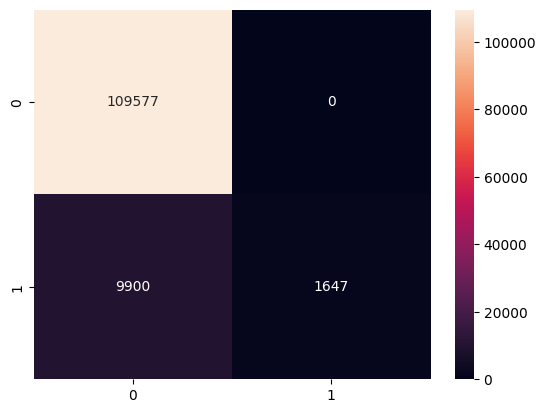

In [18]:
sns.heatmap(confusion_matrix(y_train, y_pred), annot = True, fmt = "d")

In [19]:
y_pred = classif.predict(x_test)

print('Accuracy (test) = ', accuracy_score(y_test, y_pred), 'Recall (test) = ', recall_score(y_test, y_pred),
      'Precision (test) = ', precision_score(y_test, y_pred))

Accuracy (test) =  0.917838980252295 Recall (test) =  0.14560439560439561 Precision (test) =  1.0


<Axes: >

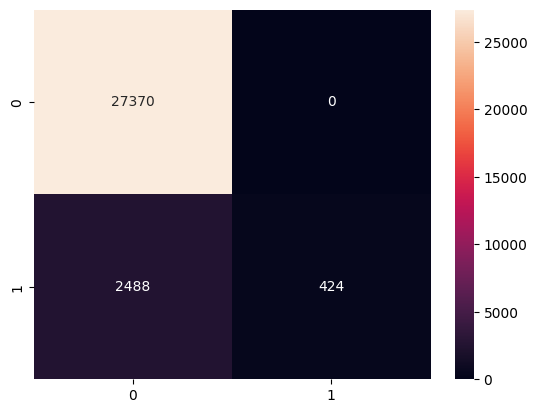

In [20]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')

In [24]:
%pip install catboost

  Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached narwhals-2.20.0-py3-none-any.whl.metadata (15 kB)
Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl (100.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.20.0-py3-none-any.whl (449 kB)
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from catboost import Pool, CatBoostClassifier

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
x.shape, y.shape

((151406, 24), (151406,))

In [27]:
train_pool = Pool(x_train,
                  y_train,
                  cat_features=['variable_5', 'variable_20', 'variable_21', 'variable_22', 'variable_28'])
test_pool = Pool(x_test,
                  cat_features=['variable_5', 'variable_20', 'variable_21', 'variable_22', 'variable_28'])

classif = CatBoostClassifier(iterations = 1000, learning_rate = 0.1, max_depth = 5)
classif.fit(train_pool)

0:	learn: 0.5973124	total: 195ms	remaining: 3m 15s
1:	learn: 0.5243842	total: 246ms	remaining: 2m 2s
2:	learn: 0.4680265	total: 296ms	remaining: 1m 38s
3:	learn: 0.4259277	total: 329ms	remaining: 1m 21s
4:	learn: 0.3868679	total: 380ms	remaining: 1m 15s
5:	learn: 0.3624959	total: 435ms	remaining: 1m 12s
6:	learn: 0.3387881	total: 488ms	remaining: 1m 9s
7:	learn: 0.3194038	total: 545ms	remaining: 1m 7s
8:	learn: 0.3063406	total: 603ms	remaining: 1m 6s
9:	learn: 0.2973813	total: 656ms	remaining: 1m 4s
10:	learn: 0.2872449	total: 711ms	remaining: 1m 3s
11:	learn: 0.2818527	total: 768ms	remaining: 1m 3s
12:	learn: 0.2753003	total: 821ms	remaining: 1m 2s
13:	learn: 0.2722482	total: 837ms	remaining: 59s
14:	learn: 0.2693863	total: 890ms	remaining: 58.5s
15:	learn: 0.2671597	total: 959ms	remaining: 59s
16:	learn: 0.2630254	total: 1.02s	remaining: 59.2s
17:	learn: 0.2614858	total: 1.08s	remaining: 58.7s
18:	learn: 0.2603815	total: 1.13s	remaining: 58.5s
19:	learn: 0.2594940	total: 1.18s	remain

CatBoostClassifier(iterations=1000, learning_rate=0.1, max_depth=5)

In [28]:
y_pred = classif.predict(x_train)

print('Accuracy (train) = ', accuracy_score(y_train, y_pred), ', Recall (train) = ', recall_score(y_train, y_pred),
      ', Precision (train) = ', precision_score(y_train, y_pred))

Accuracy (train) =  0.9306413262441795 , Recall (train) =  0.2749870533402382 , Precision (train) =  0.9996862252902416


<Axes: >

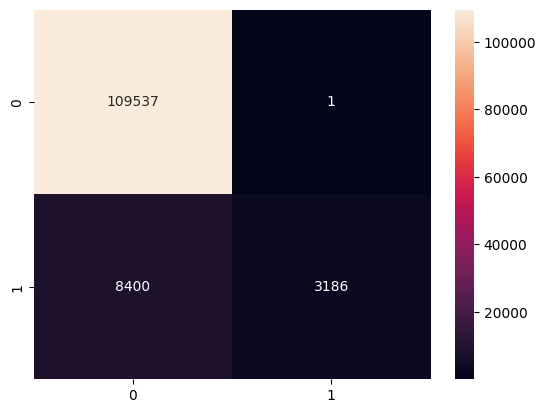

In [29]:
sns.heatmap(confusion_matrix(y_train, y_pred), annot = True, fmt = 'd')

In [30]:
y_pred = classif.predict(x_test)

print('Accuracy (test) = ', accuracy_score(y_test, y_pred), ', Recall (test) = ', recall_score(y_test, y_pred),
      ', Precision (test) = ', precision_score(y_test, y_pred))

Accuracy (test) =  0.9320058120335513 , Recall (test) =  0.28437173686042466 , Precision (test) =  0.9963414634146341


<Axes: >

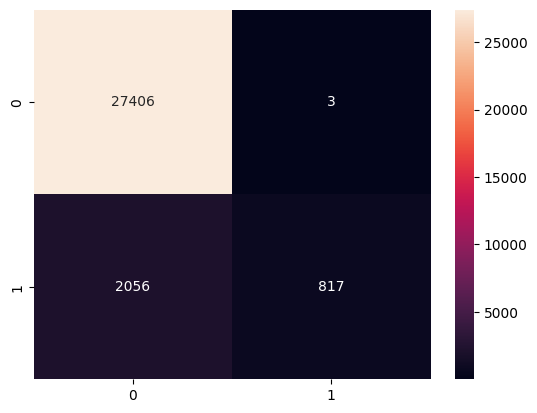

In [31]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')

In [32]:
classif = CatBoostClassifier()
classif.fit(train_pool)

Learning rate set to 0.079886
0:	learn: 0.6152822	total: 59.5ms	remaining: 59.4s
1:	learn: 0.5525438	total: 86.8ms	remaining: 43.3s
2:	learn: 0.5020719	total: 121ms	remaining: 40.3s
3:	learn: 0.4629496	total: 147ms	remaining: 36.7s
4:	learn: 0.4279083	total: 207ms	remaining: 41.2s
5:	learn: 0.4018351	total: 260ms	remaining: 43s
6:	learn: 0.3748773	total: 323ms	remaining: 45.8s
7:	learn: 0.3572724	total: 358ms	remaining: 44.4s
8:	learn: 0.3433535	total: 383ms	remaining: 42.2s
9:	learn: 0.3313613	total: 447ms	remaining: 44.3s
10:	learn: 0.3202378	total: 510ms	remaining: 45.8s
11:	learn: 0.3109943	total: 573ms	remaining: 47.2s
12:	learn: 0.3043824	total: 636ms	remaining: 48.3s
13:	learn: 0.2991563	total: 698ms	remaining: 49.2s
14:	learn: 0.2950792	total: 734ms	remaining: 48.2s
15:	learn: 0.2883949	total: 797ms	remaining: 49s
16:	learn: 0.2815629	total: 858ms	remaining: 49.6s
17:	learn: 0.2759598	total: 919ms	remaining: 50.1s
18:	learn: 0.2708831	total: 984ms	remaining: 50.8s
19:	learn: 0.

CatBoostClassifier()

In [33]:
y_pred = classif.predict(x_train)

print('Accuracy (train) = ', accuracy_score(y_train, y_pred), ', Recall (train) = ', recall_score(y_train, y_pred),
      ', Precision (train) = ', precision_score(y_train, y_pred))


Accuracy (train) =  0.9305917902314983 , Recall (train) =  0.274641809079924 , Precision (train) =  0.9990580847723705


In [34]:
y_pred = classif.predict(x_test)

print('Accuracy (test) = ', accuracy_score(y_test, y_pred), ', Recall (test) = ', recall_score(y_test, y_pred),
      ', Precision (test) = ', precision_score(y_test, y_pred))

Accuracy (test) =  0.9320058120335513 , Recall (test) =  0.28367560041768186 , Precision (test) =  0.9987745098039216


Learning rate set to 0.079886
0:	learn: 0.6145146	total: 63.3ms	remaining: 1m 3s
100:	learn: 0.2419820	total: 5.99s	remaining: 53.3s
200:	learn: 0.2386742	total: 12.1s	remaining: 48.3s
300:	learn: 0.2357067	total: 18.4s	remaining: 42.6s
400:	learn: 0.2338397	total: 24.5s	remaining: 36.6s
500:	learn: 0.2316575	total: 30.6s	remaining: 30.5s
600:	learn: 0.2299241	total: 36.8s	remaining: 24.4s
700:	learn: 0.2280011	total: 42.9s	remaining: 18.3s
800:	learn: 0.2261065	total: 49s	remaining: 12.2s
900:	learn: 0.2243433	total: 55.1s	remaining: 6.06s
999:	learn: 0.2221744	total: 1m 1s	remaining: 0us
Accuracy (train) =  0.9311284303688782 , Recall (train) =  0.27893098079916967 , Precision (train) =  0.9984520123839009
Accuracy (test) =  0.9308500099068754 , Recall (test) =  0.27752847773558853 , Precision (test) =  0.9987577639751553


<Axes: >

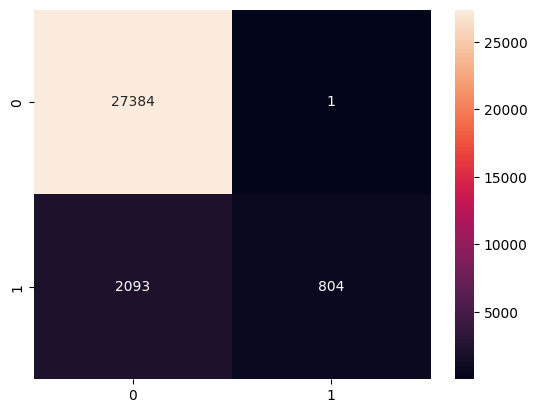

In [35]:
data['power_gr_200'] = data['variable_6'] > 200
y = data['target']
x = data.drop(columns = ['target'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
train_pool = Pool(x_train,
                  y_train,
                  cat_features=['variable_5', 'variable_20', 'variable_21', 'variable_22', 'variable_28'])
test_pool = Pool(x_test,
                  cat_features=['variable_5', 'variable_20', 'variable_21', 'variable_22', 'variable_28'])

classif = CatBoostClassifier(verbose = 100)
classif.fit(train_pool)
y_pred = classif.predict(x_train)

print('Accuracy (train) = ', accuracy_score(y_train, y_pred), ', Recall (train) = ', recall_score(y_train, y_pred),
      ', Precision (train) = ', precision_score(y_train, y_pred))

y_pred = classif.predict(x_test)

print('Accuracy (test) = ', accuracy_score(y_test, y_pred), ', Recall (test) = ', recall_score(y_test, y_pred),
      ', Precision (test) = ', precision_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')

In [36]:
classif.get_feature_importance()

array([2.74366486e+00, 3.13128504e-01, 1.75797467e+00, 2.58128350e+00,
       4.21926419e+00, 8.54011005e-01, 5.86968598e-01, 1.52711415e-01,
       5.41804130e+00, 7.35678141e+00, 8.50628509e-01, 6.13794227e-01,
       2.06859900e+00, 1.84104023e+01, 2.01340299e+01, 2.00420691e+00,
       2.75554724e+00, 4.26243991e+00, 2.50388986e-01, 1.54659324e+00,
       4.49785447e-01, 5.65281881e-01, 1.95948602e+01, 4.89559100e-01,
       2.00536975e-02])

Learning rate set to 0.079886
0:	learn: 0.6166687	total: 63.1ms	remaining: 1m 3s
100:	learn: 0.2650252	total: 5.92s	remaining: 52.7s
200:	learn: 0.2619790	total: 11.9s	remaining: 47.2s
300:	learn: 0.2593721	total: 18s	remaining: 41.9s
400:	learn: 0.2569748	total: 24.2s	remaining: 36.2s
500:	learn: 0.2549000	total: 30.5s	remaining: 30.4s
600:	learn: 0.2529955	total: 36.6s	remaining: 24.3s
700:	learn: 0.2512857	total: 42.7s	remaining: 18.2s
800:	learn: 0.2497065	total: 48.9s	remaining: 12.1s
900:	learn: 0.2479398	total: 55s	remaining: 6.04s
999:	learn: 0.2463967	total: 1m 1s	remaining: 0us
Accuracy (train) =  0.9185297711436214 , Recall (train) =  0.1643196544276458 , Precision (train) =  0.9070100143061517
Accuracy (test) =  0.9179050260881051 , Recall (test) =  0.15742024965325938 , Precision (test) =  0.8901960784313725


<Axes: >

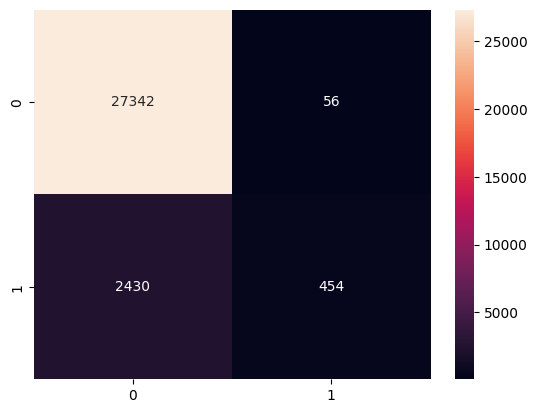

In [37]:
x = data.drop(columns = ['target', 'variable_19', 'variable_27'])
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
train_pool = Pool(x_train,
                  y_train,
                  cat_features=['variable_5', 'variable_20', 'variable_21', 'variable_22', 'variable_28'])
test_pool = Pool(x_test,
                  cat_features=['variable_5', 'variable_20', 'variable_21', 'variable_22', 'variable_28'])

classif = CatBoostClassifier(verbose = 100)
classif.fit(train_pool)
y_pred = classif.predict(x_train)

print('Accuracy (train) = ', accuracy_score(y_train, y_pred), ', Recall (train) = ', recall_score(y_train, y_pred),
      ', Precision (train) = ', precision_score(y_train, y_pred))

y_pred = classif.predict(x_test)

print('Accuracy (test) = ', accuracy_score(y_test, y_pred), ', Recall (test) = ', recall_score(y_test, y_pred),
      ', Precision (test) = ', precision_score(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt = 'd')

В кредитном и страховом скоринге всегда присутствует дисбаланс: дефолтов (или страховых случаев) значительно меньше, чем нормального поведения клиентов. Посмотрим на точные цифры, чтобы понимать масштаб проблемы.

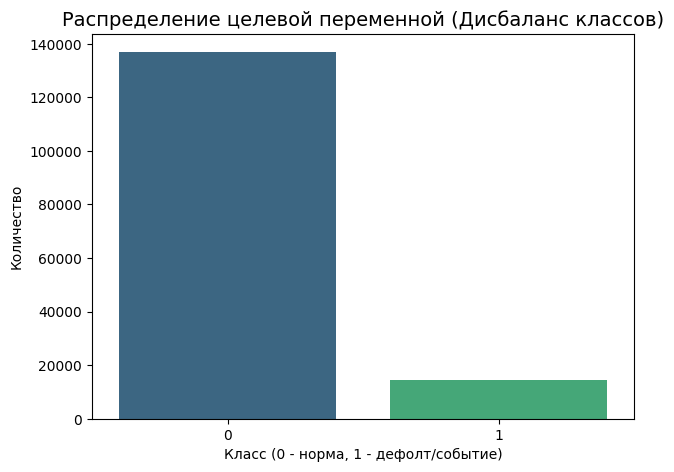

Доля классов (%):
 target
0    90.45018
1     9.54982
Name: proportion, dtype: float64


In [38]:
target_counts = data['target'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
sns.countplot(data=data, x='target', palette='viridis', hue='target', legend=False)
plt.title('Распределение целевой переменной (Дисбаланс классов)', fontsize=14)
plt.ylabel('Количество')
plt.xlabel('Класс (0 - норма, 1 - дефолт/событие)')
plt.show()

print("Доля классов (%):\n", target_counts)


Посмотрим, как числовые переменные коррелируют друг с другом. Высокая корреляция между признаками (мультиколлинеарность) может быть признаком дублирования информации. Для древесных моделей это не критично, но полезно для глубокого понимания природы данных.

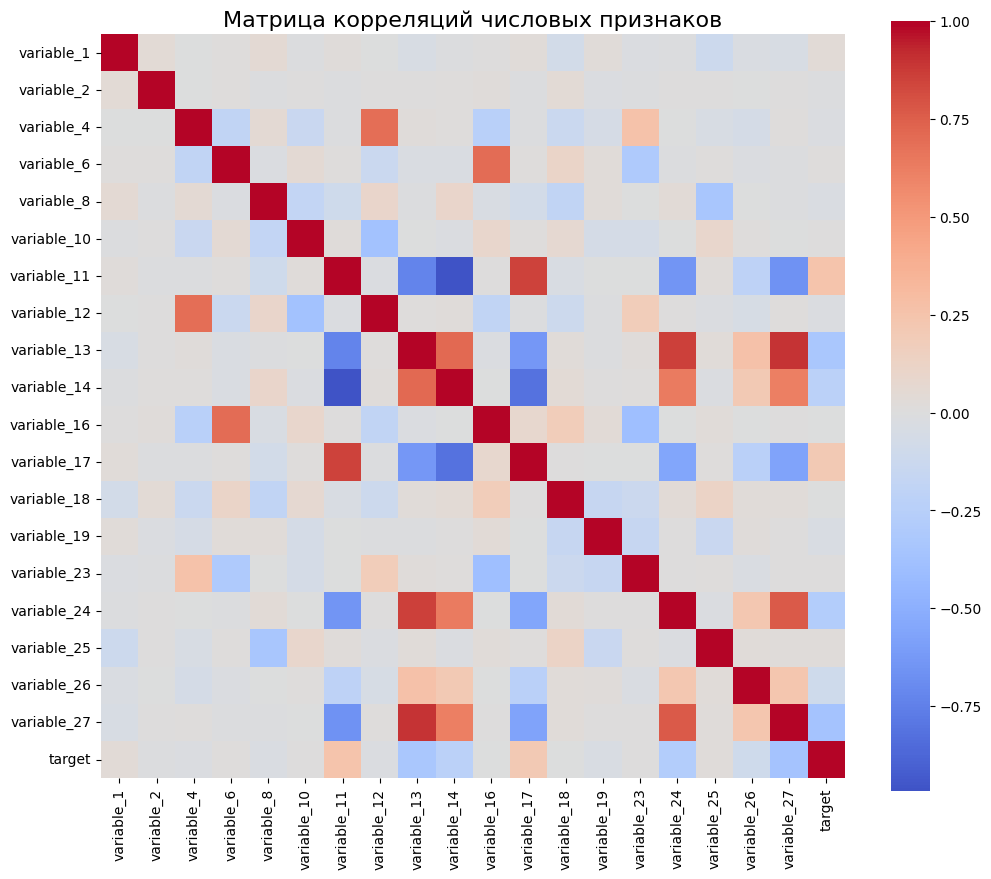

In [39]:
# Оставляем только числовые колонки для матрицы корреляций
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = data[numeric_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt='.2f', square=True)
plt.title('Матрица корреляций числовых признаков', fontsize=16)
plt.show()


Проверим датасет на наличие пропусков (NaN). Колонки, которые состоят из пропусков более чем на 80%, мы удалим, так как они вносят слишком много шума. Остальные пропуски заполним меткой 'Missing', чтобы алгоритм CatBoost воспринимал отсутствие данных как отдельную самостоятельную категорию.

In [40]:
missing_data = data.isnull().sum() / len(data) * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# Удаляем признаки с долей пропусков > 80%
columns_to_drop = missing_data[missing_data > 80].index.tolist()
print(f"Удаляем колонки из-за критического количества пропусков: {columns_to_drop}")

data_clean = data.drop(columns=columns_to_drop)

X = data_clean.drop(columns=['target'])
y = data_clean['target']

# Автоматический поиск категориальных признаков
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Обработка пропусков в категориальных переменных
X[cat_features] = X[cat_features].fillna('Missing')

# Разделение на train и test (с сохранением пропорций классов - stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")


Удаляем колонки из-за критического количества пропусков: []
Обучающая выборка: (121124, 25)
Тестовая выборка: (30282, 25)


C:\Users\DS.Yankevich\AppData\Local\Temp\ipykernel_2604\3987838150.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


Мы используем CatBoostClassifier. Зададим параметр auto_class_weights='Balanced', чтобы модель сильнее штрафовалась за ошибки на клиентах с дефолтом (так как их намного меньше). Также включим раннюю остановку (early_stopping_rounds), чтобы избежать переобучения.

In [41]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    auto_class_weights='Balanced', 
    random_seed=42,
    verbose=100
)

model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)


0:	test: 0.7027752	best: 0.7027752 (0)	total: 68.5ms	remaining: 41.1s
100:	test: 0.7458640	best: 0.7458640 (100)	total: 6.22s	remaining: 30.7s
200:	test: 0.7484755	best: 0.7484755 (200)	total: 12.1s	remaining: 24s
300:	test: 0.7498109	best: 0.7499390 (292)	total: 18.5s	remaining: 18.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7501567379
bestIteration = 344

Shrink model to first 345 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=600, learning_rate=0.05, random_seed=42, verbose=100)

По умолчанию метод .predict() относит клиента к дефолту, если вероятность события > 0.5. Но в бизнесе цена ошибки первого рода (выдать кредит банкроту) намного выше ошибки второго рода (отказать надежному). Мы построим Precision-Recall кривую и найдем порог вероятности, при котором достигается максимальный баланс (F1-score).

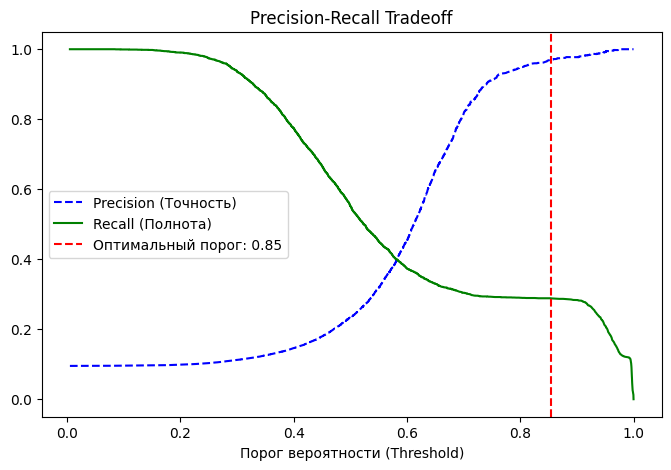

Оптимальный порог классификации: 0.8536


In [43]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
# Получаем вероятности принадлежности к классу 1
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Вычисляем precision, recall и thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Избегаем деления на ноль при расчете F1
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls)!=0)

# Находим индекс максимального F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Точность)')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Полнота)')
plt.axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Оптимальный порог: {optimal_threshold:.2f}')
plt.title('Precision-Recall Tradeoff')
plt.xlabel('Порог вероятности (Threshold)')
plt.legend()
plt.show()

print(f"Оптимальный порог классификации: {optimal_threshold:.4f}")


Применим найденный оптимальный порог к нашим предсказаниям и посмотрим на Матрицу ошибок. Затем выведем ТОП-15 признаков, которые оказали наибольшее влияние на решения модели.


ROC-AUC Score: 0.7502

Отчет по классификации (С оптимальным порогом):
              precision    recall  f1-score   support

           0       0.93      1.00      0.96     27390
           1       0.97      0.29      0.45      2892

    accuracy                           0.93     30282
   macro avg       0.95      0.64      0.70     30282
weighted avg       0.93      0.93      0.91     30282



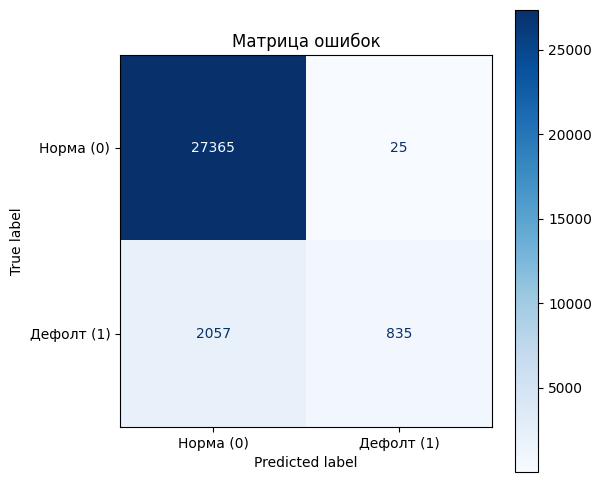

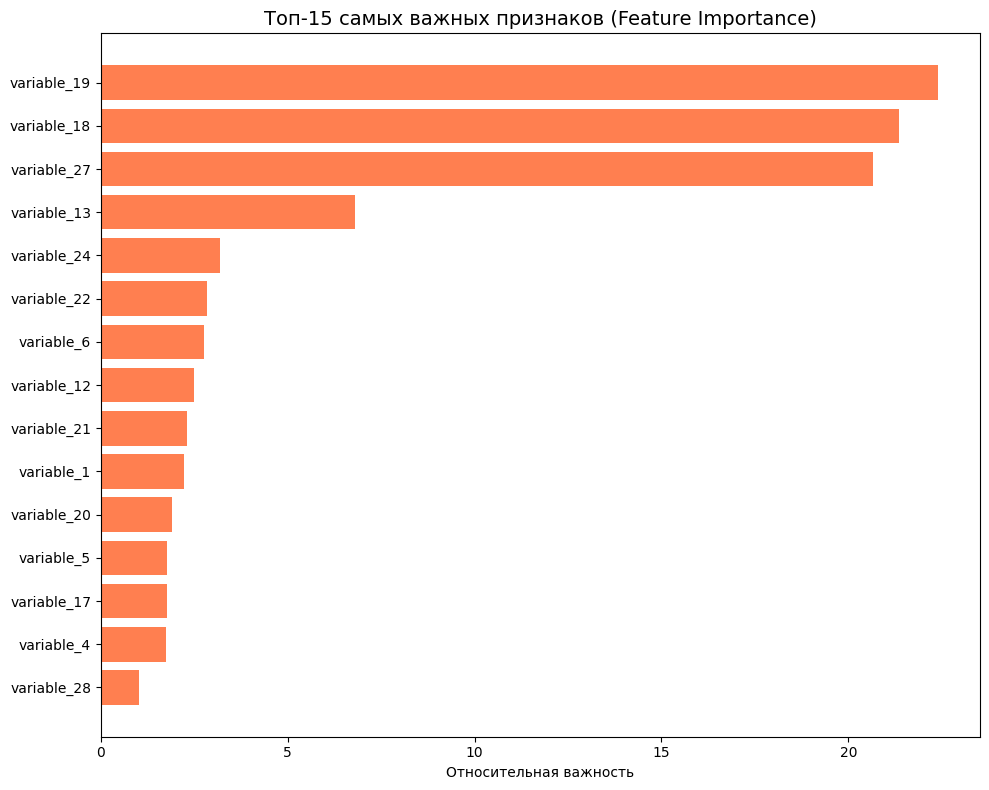

In [45]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Применяем новый порог
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# Метрика ROC-AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {auc_score:.4f}\n")

print("Отчет по классификации (С оптимальным порогом):")
print(classification_report(y_test, y_pred_optimal))

# Визуализация матрицы ошибок
cm = confusion_matrix(y_test, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Норма (0)', 'Дефолт (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Матрица ошибок')
plt.grid(False)
plt.show()

# Важность признаков
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

top_n = 15
top_idx = sorted_idx[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), feature_importance[top_idx], align='center', color='coral')
plt.yticks(range(top_n), np.array(X.columns)[top_idx])
plt.title(f'Топ-{top_n} самых важных признаков (Feature Importance)', fontsize=14)
plt.xlabel('Относительная важность')
plt.tight_layout()
plt.show()
